In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(style='darkgrid', palette='Dark2')

In [3]:
data=pd.read_csv('maintainance.csv')
data

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


<Axes: ylabel='Density'>

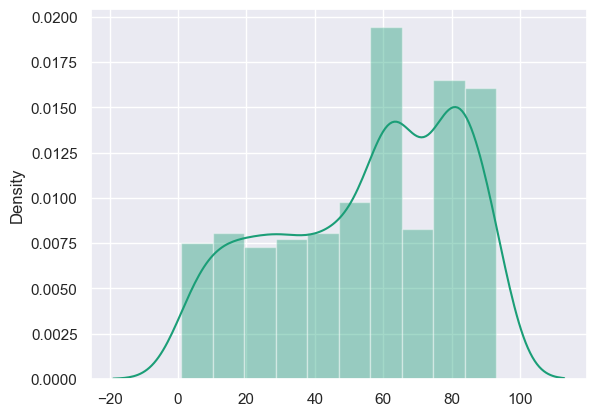

In [4]:
sns.distplot(x=data.lifetime)

<Axes: xlabel='broken', ylabel='count'>

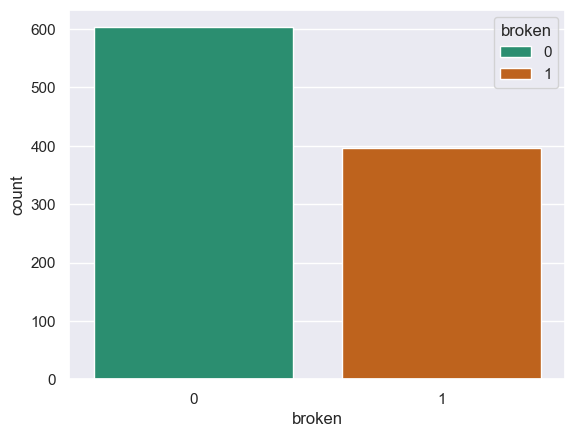

In [5]:
sns.countplot(x=data.broken , hue=data.broken)

In [6]:
data.columns=['lifetime' , 'broken' , 'pressure' , 'moisture' ,'temperature' , 'team' , 'provider']
data

,lifetime,broken,pressure,moisture,temperature,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


## as the lifetime increases above 58 55 , then the machines brakes mostly 

<Axes: xlabel='moisture', ylabel='lifetime'>

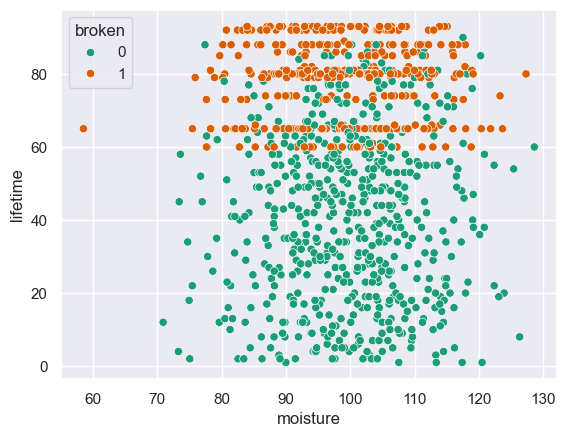

In [7]:
sns.scatterplot(x=data.moisture , y=data.lifetime , hue=data.broken)

<Axes: xlabel='provider', ylabel='lifetime'>

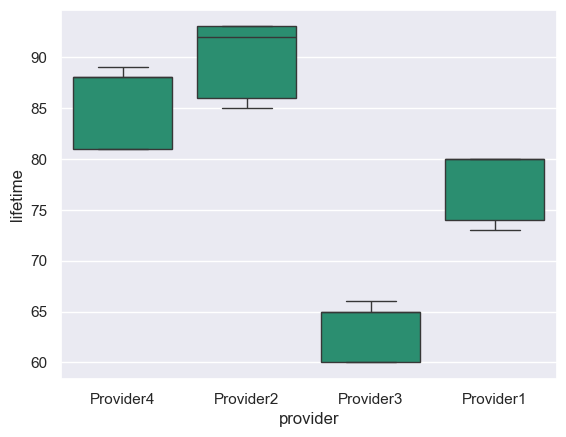

In [8]:
sns.boxplot(x=data.provider[data.broken==1] , y=data.lifetime)

<Axes: xlabel='provider', ylabel='count'>

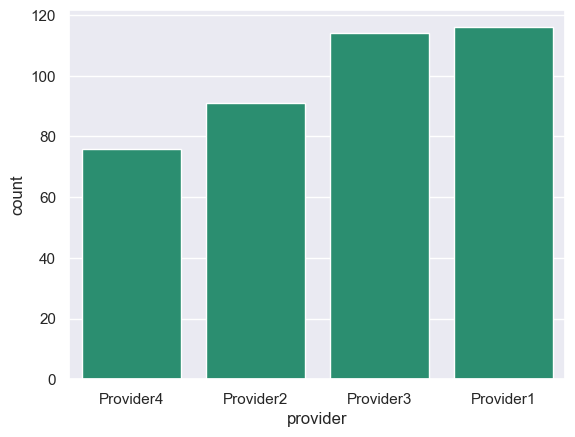

In [9]:
sns.countplot(x=data.provider[data.broken==1])

array(['Provider4', 'Provider1', 'Provider2', 'Provider3'], dtype=object)

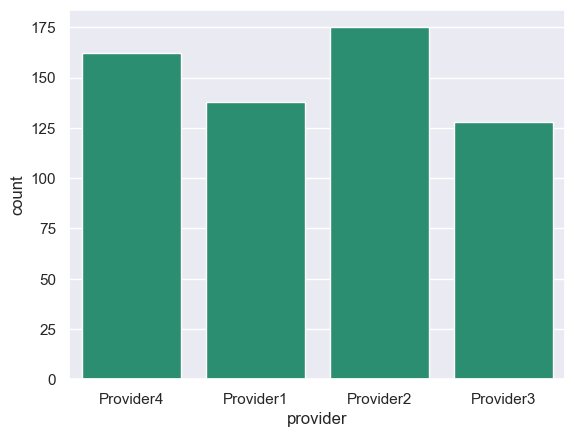

In [10]:
sns.countplot(x=data.provider[data.broken==0])
data.provider.unique()

In [11]:
from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# ct=ColumnTransformer([
#     ('team',OneHotEncoder(),['team']),
#     ('provider',OneHotEncoder(),['provider'])
# ] , remainder='passthrough')

# inputs = data.drop(['broken'] , axis=1)

# output=data.broken

# inputs=np.array(ct.fit_transform(inputs))

i = data[['provider','team']]

oh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = oh.fit_transform(i)

encoded_columns = oh.get_feature_names_out(['provider', 'team'])

encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns)
data = data.drop(['provider' , 'team'],axis=1)
data = pd.concat([data, encoded_df], axis=1)
data


,lifetime,broken,pressure,moisture,temperature,provider_Provider1,provider_Provider2,provider_Provider3,provider_Provider4,team_TeamA,team_TeamB,team_TeamC
0,56,0,92.178854,104.230204,96.517159,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,81,1,72.075938,103.065701,87.271062,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,60,0,96.272254,77.801376,112.196170,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,86,1,94.406461,108.493608,72.025374,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,34,0,97.752899,99.413492,103.756271,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,0.0,0.0,0.0,1.0,0.0,1.0,0.0
996,88,1,116.727075,110.871332,95.075631,0.0,0.0,0.0,1.0,1.0,0.0,0.0
997,22,0,104.026778,88.212873,83.221220,1.0,0.0,0.0,0.0,0.0,1.0,0.0
998,78,0,104.911649,104.257296,83.421491,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [32]:
inputs = data.drop(['broken'],axis=1)
output = data.broken
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lifetime            1000 non-null   int64  
 1   broken              1000 non-null   int64  
 2   pressure            1000 non-null   float64
 3   moisture            1000 non-null   float64
 4   temperature         1000 non-null   float64
 5   provider_Provider1  1000 non-null   float64
 6   provider_Provider2  1000 non-null   float64
 7   provider_Provider3  1000 non-null   float64
 8   provider_Provider4  1000 non-null   float64
 9   team_TeamA          1000 non-null   float64
 10  team_TeamB          1000 non-null   float64
 11  team_TeamC          1000 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 93.9 KB


lifetime              0
broken                0
pressure              0
moisture              0
temperature           0
provider_Provider1    0
provider_Provider2    0
provider_Provider3    0
provider_Provider4    0
team_TeamA            0
team_TeamB            0
team_TeamC            0
dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(inputs , output , test_size=0.1)

In [14]:
from sklearn.linear_model import LogisticRegression 
alg=LogisticRegression()
from sklearn.preprocessing import StandardScaler
# sc = StandardScaler()

# x_train = sc.fit_transform(x_train)
# x_test = sc.fit_transform(x_test)

alg.fit(x_train , y_train)
yp=alg.predict(x_test)

In [15]:
# from sklearn.metrics import confusion_matrix 
# confusion_matrix(y_test ,yp )

In [16]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score
print(accuracy_score(y_test,yp))
print(recall_score(y_test,yp))
print(f1_score(y_test,yp))
print(precision_score(y_test,yp))

0.95
1.0
0.9494949494949495
0.9038461538461539


In [17]:
# Not giving good results

from sklearn.neighbors import KNeighborsClassifier
alg=KNeighborsClassifier(n_neighbors=100)
alg.fit(x_train , y_train)
yp=alg.predict(x_test)

print(accuracy_score(y_test,yp))
print(recall_score(y_test,yp))
print(f1_score(y_test,yp))
print(precision_score(y_test,yp))

0.84
0.7659574468085106
0.8181818181818182
0.8780487804878049


In [18]:
from sklearn.tree import DecisionTreeClassifier
alg = DecisionTreeClassifier()
alg.fit(x_train,y_train)
yp = alg.predict(x_test)
print(accuracy_score(y_test,yp))
print(recall_score(y_test,yp))
print(f1_score(y_test,yp))
print(precision_score(y_test,yp))

0.98
1.0
0.9791666666666666
0.9591836734693877


In [19]:
from sklearn.ensemble import RandomForestClassifier
alg = RandomForestClassifier(n_estimators=100 , random_state=42)
alg.fit(x_train,y_train)
yp = alg.predict(x_test)
print(accuracy_score(y_test,yp))
print(recall_score(y_test,yp))
print(f1_score(y_test,yp))
print(precision_score(y_test,yp))

0.97
1.0
0.9690721649484536
0.94
